<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-9-Stochastically_Informed-NN/Untitled179.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Calibrating Geometric Brownian Motion**

Generating a few simulations:

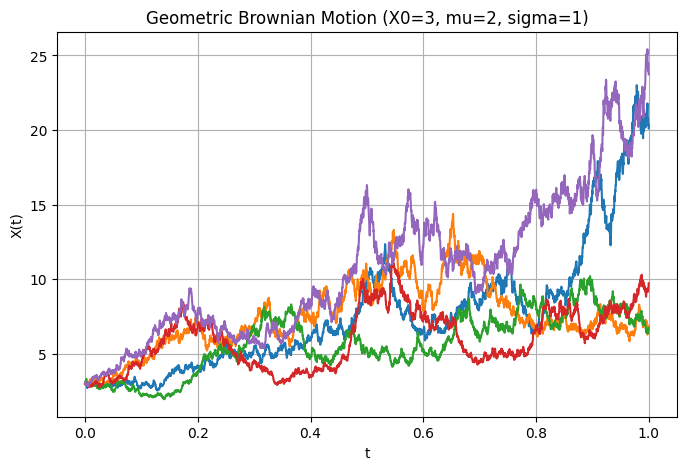

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
X0 = 3.0
mu = 2.0
sigma = 1.0

T = 1.0
N = 3000                 # number of time steps
dt = T / N

n_paths = 5              # number of trajectories

t = np.linspace(0, T, N+1)

# =========================
# Simulation (exact scheme)
# =========================
X = np.zeros((n_paths, N+1))
X[:, 0] = X0

for k in range(N):
    xi = np.random.randn(n_paths)
    X[:, k+1] = X[:, k] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * xi
    )

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))

for i in range(n_paths):
    plt.plot(t, X[i], lw=1.5)

plt.title("Geometric Brownian Motion (X0=3, mu=2, sigma=1)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.show()

True parameters:
mu = 2.0, sigma = 1.0

Estimated parameters:
mu_hat    = 2.16000
sigma_hat = 0.94223


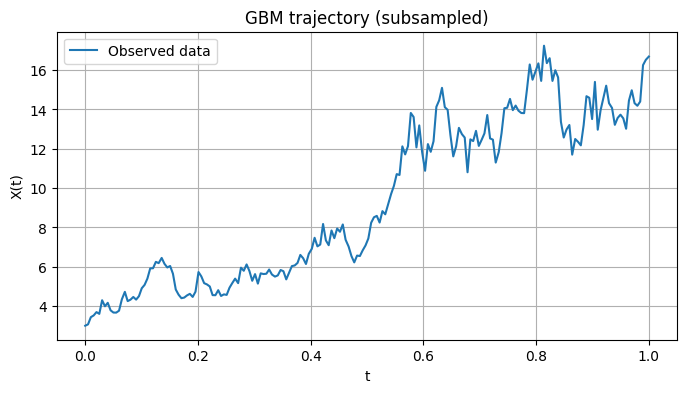

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# Parameters (true)
# =========================
X0 = 3.0
mu_true = 2.0
sigma_true = 1.0

T = 1.0
N_total = 3000
dt = T / N_total

# =========================
# 1. Simulate GBM (exact)
# =========================
X = np.zeros(N_total + 1)
X[0] = X0

for k in range(N_total):
    xi = np.random.randn()
    X[k+1] = X[k] * np.exp(
        (mu_true - 0.5 * sigma_true**2) * dt
        + sigma_true * np.sqrt(dt) * xi
    )

# =========================
# 2. Subsample N = 200
# =========================
N = 200
indices = np.linspace(0, N_total, N).astype(int)

X_data = X[indices]
t_data = indices * dt

# Convert to TensorFlow
X_tf = tf.constant(X_data, dtype=tf.float32)
t_tf = tf.constant(t_data, dtype=tf.float32)

# =========================
# 3. Compute estimators (TF)
# =========================

# log-increments
log_increments = tf.math.log(X_tf[1:] / X_tf[:-1])

# term 1
term1 = tf.reduce_sum(log_increments**2)

# term 2
term2 = (tf.math.log(X_tf[-1] / X_tf[0]))**2 / (N - 1)

# sigma estimator
sigma_hat = tf.sqrt((term1 - term2) / (t_tf[-1] - t_tf[0]))

# mu estimator
mu_hat = (
    tf.math.log(X_tf[-1] / X_tf[0]) / (t_tf[-1] - t_tf[0])
    + 0.5 * sigma_hat**2
)

# =========================
# 4. Output
# =========================
print("True parameters:")
print(f"mu = {mu_true}, sigma = {sigma_true}")

print("\nEstimated parameters:")
print(f"mu_hat    = {mu_hat.numpy():.5f}")
print(f"sigma_hat = {sigma_hat.numpy():.5f}")

# =========================
# 5. Plot trajectory
# =========================
plt.figure(figsize=(8,4))
plt.plot(t_data, X_data, label="Observed data")
plt.title("GBM trajectory (subsampled)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.legend()
plt.show()

Monte-Carlo simulation for 10,000 trials. we plot the distributions of paraemeters.

<>:73: SyntaxWarning: invalid escape sequence '\h'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\h'
<>:84: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\h'
<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\h'
<>:84: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30177/4007040984.py:73: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Distribution of $\hat{\mu}$")
/tmp/ipykernel_30177/4007040984.py:74: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$\mu$")
/tmp/ipykernel_30177/4007040984.py:83: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Distribution of $\hat{\sigma}$")
/tmp/ipykernel_30177/4007040984.py:84: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sigma$")


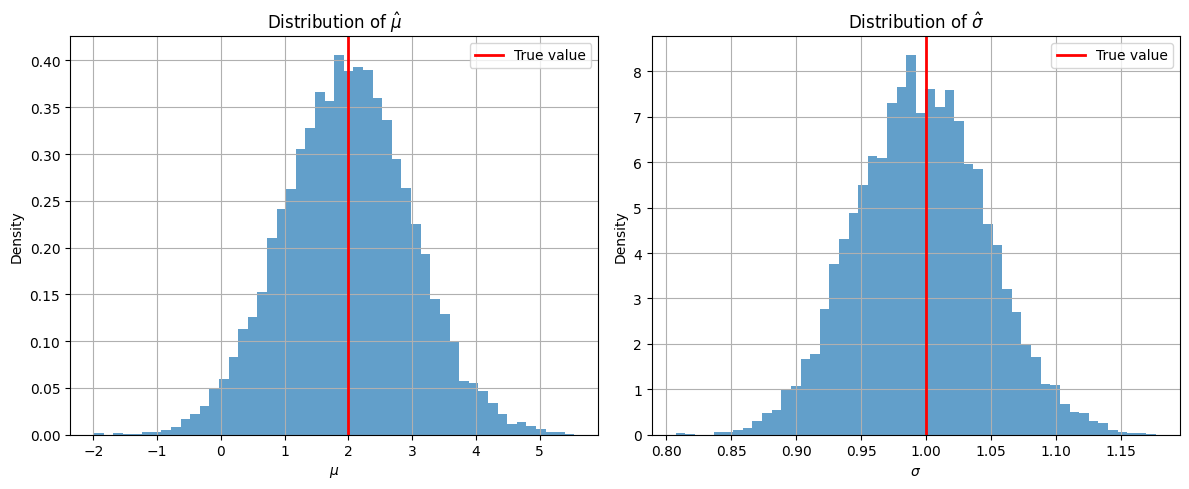

Mu:    mean = 1.989814444800449 std = 1.0024360588689298
Sigma: mean = 0.9962799764033338 std = 0.049894914519853006


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# True parameters
# =========================
X0 = 3.0
mu_true = 2.0
sigma_true = 1.0

T = 1.0
N_total = 3000
dt = T / N_total

# Subsample size
N = 200

# Monte Carlo runs
M = 10000

mu_estimates = np.empty(M)
sigma_estimates = np.empty(M)

# Precompute subsampling indices
indices = np.linspace(0, N_total, N).astype(int)

for m in range(M):
    # =========================
    # Simulate GBM (exact)
    # =========================
    X = np.zeros(N_total + 1)
    X[0] = X0

    for k in range(N_total):
        xi = np.random.randn()
        X[k+1] = X[k] * np.exp(
            (mu_true - 0.5 * sigma_true**2) * dt
            + sigma_true * np.sqrt(dt) * xi
        )

    # =========================
    # Subsample N = 200
    # =========================
    X_data = X[indices]
    t_data = indices * dt

    # =========================
    # Compute estimators
    # =========================
    log_inc = np.log(X_data[1:] / X_data[:-1])

    term1 = np.sum(log_inc**2)
    term2 = (np.log(X_data[-1] / X_data[0]))**2 / (N - 1)

    sigma_hat = np.sqrt((term1 - term2) / (t_data[-1] - t_data[0]))
    mu_hat = (
        np.log(X_data[-1] / X_data[0]) / (t_data[-1] - t_data[0])
        + 0.5 * sigma_hat**2
    )

    sigma_estimates[m] = sigma_hat
    mu_estimates[m] = mu_hat

# =========================
# Plot histograms
# =========================
plt.figure(figsize=(12,5))

# ---- mu histogram
plt.subplot(1,2,1)
plt.hist(mu_estimates, bins=50, density=True, alpha=0.7)
plt.axvline(mu_true, color='red', linewidth=2, label="True value")
plt.title("Distribution of $\hat{\mu}$")
plt.xlabel("$\mu$")
plt.ylabel("Density")
plt.legend()
plt.grid()

# ---- sigma histogram
plt.subplot(1,2,2)
plt.hist(sigma_estimates, bins=50, density=True, alpha=0.7)
plt.axvline(sigma_true, color='red', linewidth=2, label="True value")
plt.title("Distribution of $\hat{\sigma}$")
plt.xlabel("$\sigma$")
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# =========================
# Summary statistics
# =========================
print("Mu:    mean =", np.mean(mu_estimates), "std =", np.std(mu_estimates))
print("Sigma: mean =", np.mean(sigma_estimates), "std =", np.std(sigma_estimates))